This project analyzes a movie dataset containing 1,500 movies to identify trends in ratings, budgets, revenues, genres, directors, and release years. Using Python libraries such as NumPy, Pandas, and Matplotlib, the project performs data cleaning, statistical analysis, grouped analysis, and data visualization to extract meaningful insights from the dataset.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

#DATA LOADING
df = pd.read_csv('/content/movie_dataset_1500.csv')

#INSPECTION
print(df.head())
print(df.info())
print(df.describe())


   movie_id    title  year     genre    director  rating     budget    revenue
0         1  Movie_1  2006     Drama  Director_E     6.9  187980505   81778368
1         2  Movie_2  2019    Comedy  Director_C     6.4   69709584  700005464
2         3  Movie_3  2014     Drama  Director_E     7.8   87491407   12707690
3         4  Movie_4  2010  Thriller  Director_E     7.1   88105678  817309989
4         5  Movie_5  2007   Romance  Director_A     6.6  124625058  384527763
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   movie_id  1500 non-null   int64  
 1   title     1500 non-null   object 
 2   year      1500 non-null   int64  
 3   genre     1500 non-null   object 
 4   director  1500 non-null   object 
 5   rating    1500 non-null   float64
 6   budget    1500 non-null   int64  
 7   revenue   1500 non-null   int64  
dtypes: float64(1), int64(4), 

In [ ]:
#DATA CLEANING
# title case change of all column names
df.columns = df.columns.str.title()

# changing data type
df.loc[:, 'Revenue'] = df['Revenue'].astype(float)
df.loc[:, 'Budget'] = df['Budget'].astype(float)

print(df.info())

# introduce missing values
df.loc[0:20, 'Rating'] = None
df.loc[40:60, 'Budget'] = None

print(df.isnull().sum())

# filling missing values
df.loc[:, 'Rating'] = df['Rating'].fillna(df['Rating'].mean())
df.loc[:, 'Budget'] = df['Budget'].fillna(df['Budget'].median())

# remove duplicate columns
df = df.loc[:, ~df.columns.duplicated()]

print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Movie_Id  1500 non-null   int64  
 1   Title     1500 non-null   object 
 2   Year      1500 non-null   int64  
 3   Genre     1500 non-null   object 
 4   Director  1500 non-null   object 
 5   Rating    1500 non-null   float64
 6   Budget    1500 non-null   float64
 7   Revenue   1500 non-null   float64
dtypes: float64(3), int64(2), object(3)
memory usage: 93.9+ KB
None
Movie_Id     0
Title        0
Year         0
Genre        0
Director     0
Rating      21
Budget      21
Revenue      0
dtype: int64
Movie_Id    0
Title       0
Year        0
Genre       0
Director    0
Rating      0
Budget      0
Revenue     0
dtype: int64


In [ ]:
#Statistical Analysis with NumPy

#Compute mean, median, and standard deviation of movie ratings.

print('RATING')
mov_rate = df['Rating']
print('Mean: ', np.mean(mov_rate))
print('Median: ', np.median(mov_rate))
print('Standard Deviation: ', np.std(mov_rate))

#similar analysis on budget and revenue

print('\nBUDGET')
bud_val = df['Budget']
print('Mean: ', np.mean(bud_val))
print('Median: ', np.median(bud_val))
print('Standard Deviation: ', np.std(bud_val))

#revenue
print('\nREVENUE')
rev_val = df['Revenue']
print('Mean: ', np.mean(rev_val))
print('Median: ', np.median(rev_val))
print('Standard Deviation: ', np.std(rev_val))


RATING
Mean:  6.2298850574712645
Median:  6.2298850574712645
Standard Deviation:  1.8474124391446847

BUDGET
Mean:  97584460.87266667
Median:  93759975.0
Standard Deviation:  58153637.546545625

REVENUE
Mean:  505338722.79
Median:  512029870.5
Standard Deviation:  287310842.8597097


In [ ]:
#Grouped Analysis with Pandas

#Group by Genre and compute average ratings for better view i changed mean as Avg_rate

avg_rating = df.groupby('Genre').agg(Avg_rate =('Rating','mean')).reset_index()
print("Genre Analysis")
print(avg_rating)

#Group by Director to analyze average rating per director.

dir_rating = df.groupby('Director').agg(Avg_rate =('Rating','mean')).reset_index()
print("\nDirector Analysis")
print(dir_rating)

#Group by Year to analyze rating trends over time.

year_rating = df.groupby('Year').agg(Avg_rate =('Rating','mean')).reset_index()
print("\nYear Analysis")
print(year_rating)

Genre Analysis
      Genre  Avg_rate
0    Action  6.294855
1    Comedy  6.175308
2     Drama  6.299212
3    Horror  6.157664
4   Romance  6.164043
5    Sci-Fi  6.342263
6  Thriller  6.197327

Director Analysis
     Director  Avg_rate
0  Director_A  6.283502
1  Director_B  6.049390
2  Director_C  6.271637
3  Director_D  6.262625
4  Director_E  6.254898

Year Analysis
    Year  Avg_rate
0   2000  6.212658
1   2001  6.369217
2   2002  6.318087
3   2003  5.955498
4   2004  6.093333
5   2005  6.436842
6   2006  6.356203
7   2007  6.343095
8   2008  6.245455
9   2009  6.401887
10  2010  5.931880
11  2011  6.101587
12  2012  6.010526
13  2013  6.398039
14  2014  6.139252
15  2015  6.701961
16  2016  6.040789
17  2017  5.404167
18  2018  6.350415
19  2019  6.688034
20  2020  6.027116
21  2021  6.200427
22  2022  6.421548
23  2023  6.354062


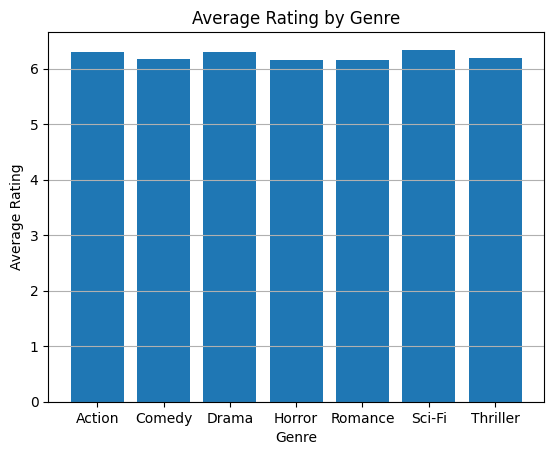

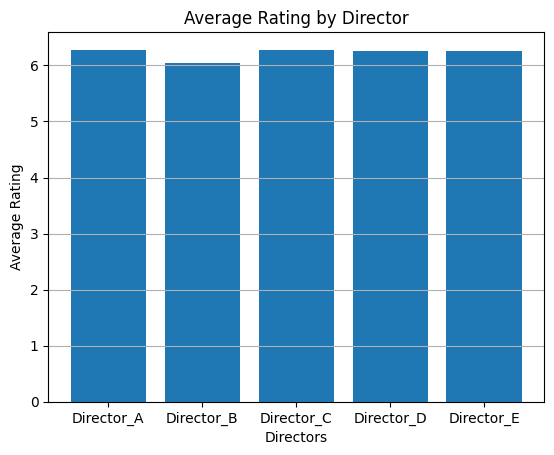

In [ ]:
#Visualizations with Matplotlib

#Bar Plot: Show average rating by genre and by director.

#by genere
plt.figure()
plt.bar(avg_rating['Genre'],avg_rating['Avg_rate'])
plt.xlabel('Genre')
plt.ylabel('Average Rating')
plt.title('Average Rating by Genre')
plt.grid(axis='y')
plt.show()

#by director
plt.figure()
plt.bar(dir_rating['Director'],dir_rating['Avg_rate'])
plt.xlabel('Directors')
plt.ylabel('Average Rating')
plt.title('Average Rating by Director')
plt.grid(axis='y')
plt.show()

#we can also combine the genere and director data and find out avg rating after that create a pivot
#with the help of combo data and then create a plot with that


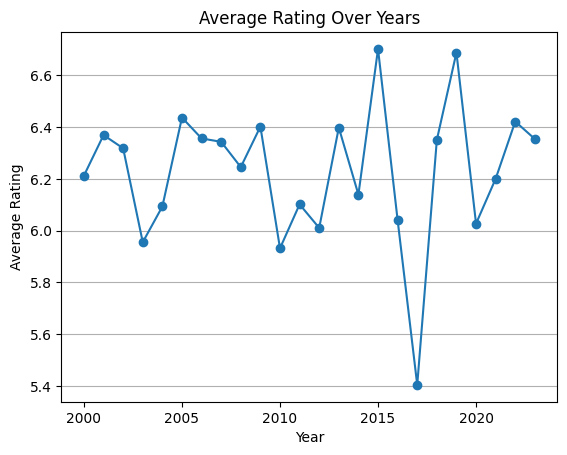

In [ ]:
#Line Plot: Display average ratings over years.

plt.figure()
plt.plot(year_rating['Year'],year_rating['Avg_rate'],marker='o')
plt.xlabel('Year')
plt.ylabel('Average Rating')
plt.title('Average Rating Over Years')
plt.grid(axis='y')
plt.show()

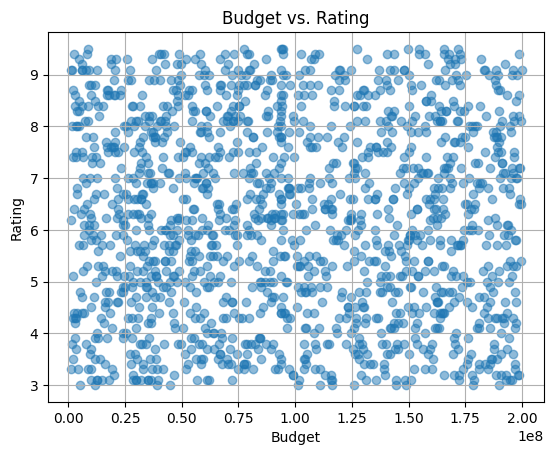

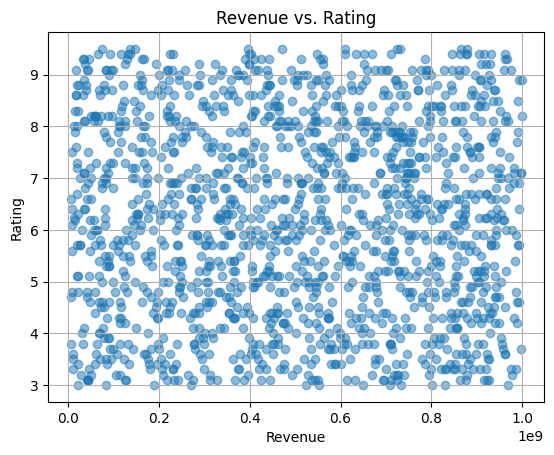

In [ ]:
#Scatter Plot: Budget vs. Rating, Revenue vs. Rating.

#Budget vs Rating
plt.figure()
plt.scatter(df['Budget'],df['Rating'],alpha=0.5)
plt.xlabel('Budget')
plt.ylabel('Rating')
plt.title('Budget vs. Rating')
plt.grid(True)
plt.show()

#Revenue vs Rating

plt.figure()
plt.scatter(df['Revenue'],df['Rating'],alpha=0.5)
plt.xlabel('Revenue')
plt.ylabel('Rating')
plt.title('Revenue vs. Rating')
plt.grid(True)
plt.show()


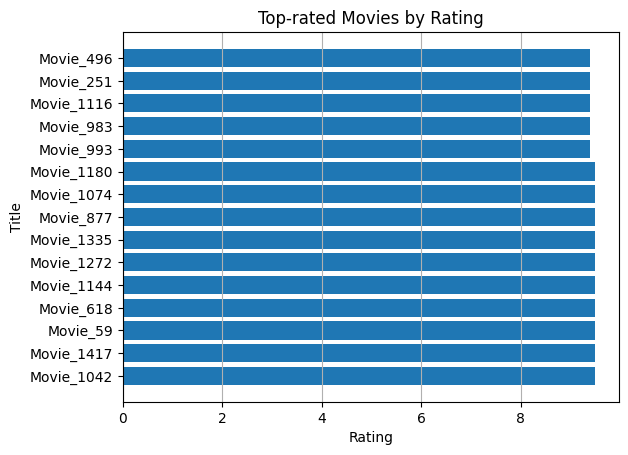

In [ ]:
#Horizontal Bar Plot: Top-rated movies by rating.

top_rated = df.sort_values(by='Rating',ascending=False).head(15)

plt.figure()
plt.barh(top_rated['Title'],top_rated['Rating'])
plt.xlabel('Rating')
plt.ylabel('Title')
plt.title('Top-rated Movies by Rating')
plt.grid(axis='x')
plt.show()

🧹 Data Cleaning

The following preprocessing steps were performed:

Standardized column names using title case formatting.
Converted Budget and Revenue columns to float data type.
Introduced missing values for demonstration purposes.
Filled missing Rating values using the mean.
Filled missing Budget values using the median.
Verified that no missing values remained after cleaning.
📊 Statistical Analysis Using NumPy

Statistical measures were calculated for:

Rating
Mean
Median
Standard Deviation
Budget
Mean
Median
Standard Deviation
Revenue
Mean
Median
Standard Deviation

These statistics provide insights into the central tendency and variability of movie performance metrics.

📈 Grouped Analysis Using Pandas
Genre Analysis

Average movie ratings were calculated for each genre.

Findings:
Sci-Fi received the highest average rating.
Horror received the lowest average rating.
Ratings across genres remained relatively consistent.
Director Analysis

Average ratings were calculated for each director.

Findings:
Director_A achieved the highest average rating.
Director_B had the lowest average rating.
Differences among directors were minimal.
Year-wise Analysis

Average ratings were calculated for each release year.

Findings:
Highest average rating observed in 2015.
Lowest average rating observed in 2017.
Ratings remained fairly stable across years.

📊 Data Visualizations
1. Bar Plot: Average Rating by Genre

Visualizes how ratings differ across movie genres.

2. Bar Plot: Average Rating by Director

Compares average ratings among directors.

3. Line Plot: Average Rating by Year

Displays rating trends over time.

4. Scatter Plot: Budget vs Rating

Examines the relationship between production budget and movie ratings.

5. Scatter Plot: Revenue vs Rating

Analyzes whether higher revenue is associated with higher ratings.

6. Horizontal Bar Plot: Top-Rated Movies

Highlights movies with the highest ratings in the dataset.